<a href="https://colab.research.google.com/github/mathgenhigh/AI-stuff/blob/main/Practive4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

Fetching MNIST dataset...


In [24]:
# 2. Check how the data looks, how many samples you have, what is the structure of the data. Save the information in log file.
# 3. Access images and labels as .data and .target
print("Fetching MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target

n_samples, n_features = X.shape
pixel_min, pixel_max = X.min(), X.max()
unique_labels = np.unique(y)

log_content = [
    "=== MNIST_784 DATA STRUCTURE LOG ===",
    f"Samples: {n_samples}",
    f"Features: {n_features}",
    f"Pixel Min: {pixel_min}",
    f"Pixel Max: {pixel_max}",
    f"Unique Labels: {unique_labels}",
    "===================================="
]

with open("data_structure_log.txt", "w") as log_file:
    log_file.write("\n".join(log_content))

for line in log_content:
    print(line)


Fetching MNIST dataset...
=== MNIST_784 DATA STRUCTURE LOG ===
Samples: 70000
Features: 784
Pixel Min: 0
Pixel Max: 255
Unique Labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


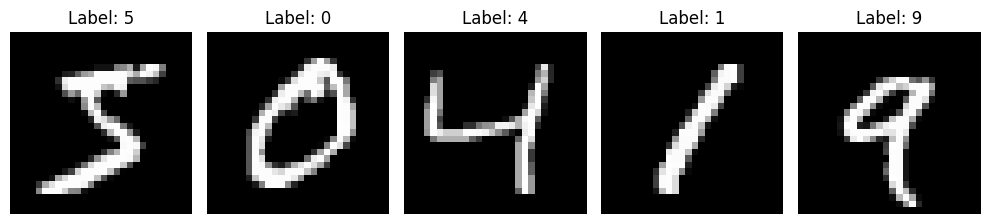

In [23]:
# 4. Show few sample handwritten digits with labels
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(X[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [25]:
# 5. Split the data into training and test
# Standard split is 60k train / 10k test, but here we use 80/20 for demonstration
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# 6. Train the Multinomial Naive Bayes model
# MultinomialNB is used because pixels are discrete count-like values (0-255)
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

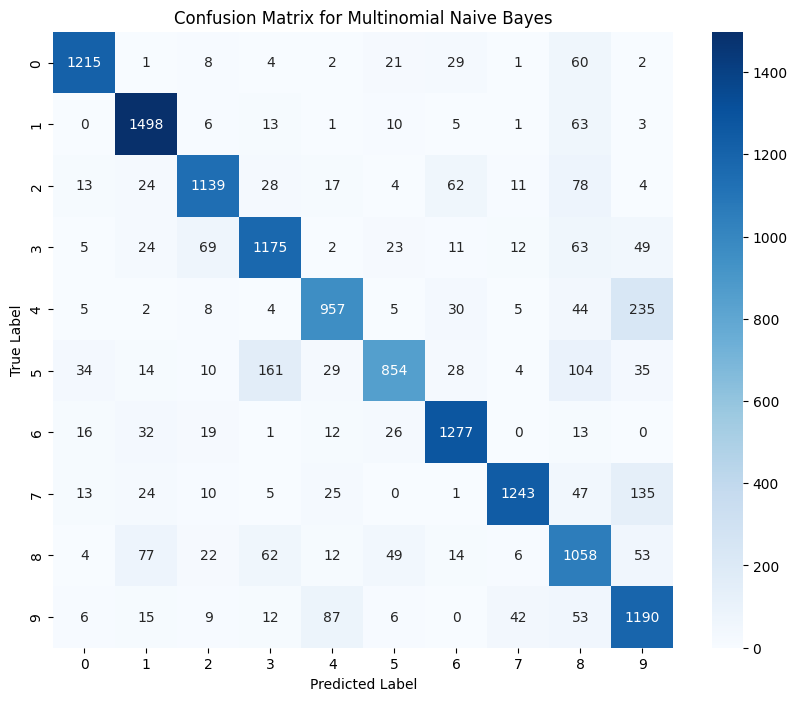

In [28]:
# 7. Predictions and Graphical Confusion Matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix for Multinomial Naive Bayes")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [29]:
# 8. Accuracy and Error Rate for each class
overall_accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Test Accuracy: {overall_accuracy:.4f}")


Overall Test Accuracy: 0.8290


In [31]:
# Calculate Error Rate per class: 1 - (TP / Total in Class)
class_totals = cm.sum(axis=1)
class_correct = np.diag(cm)
error_rates = 1 - (class_correct / class_totals)

print("\nError Rate per Class:")
for i, error in enumerate(error_rates):
    print(f"Digit {i}: {error:.4f}")


Error Rate per Class:
Digit 0: 0.0953
Digit 1: 0.0637
Digit 2: 0.1746
Digit 3: 0.1800
Digit 4: 0.2610
Digit 5: 0.3291
Digit 6: 0.0852
Digit 7: 0.1730
Digit 8: 0.2203
Digit 9: 0.1620
